--2025-12-11 12:31:42--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.data.1’

adult.data.1            [      <=>           ]   3.79M   789KB/s    in 7.0s    

2025-12-11 12:31:49 (558 KB/s) - ‘adult.data.1’ saved [3974305]

--2025-12-11 12:31:49--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.test.1’

adult.test.1            [                 <=>]   1.91M   468KB/s    in 4.3s    

2025-12-11 12:31:55 (460 KB/s) - ‘adult.test.1’ saved [2003153]



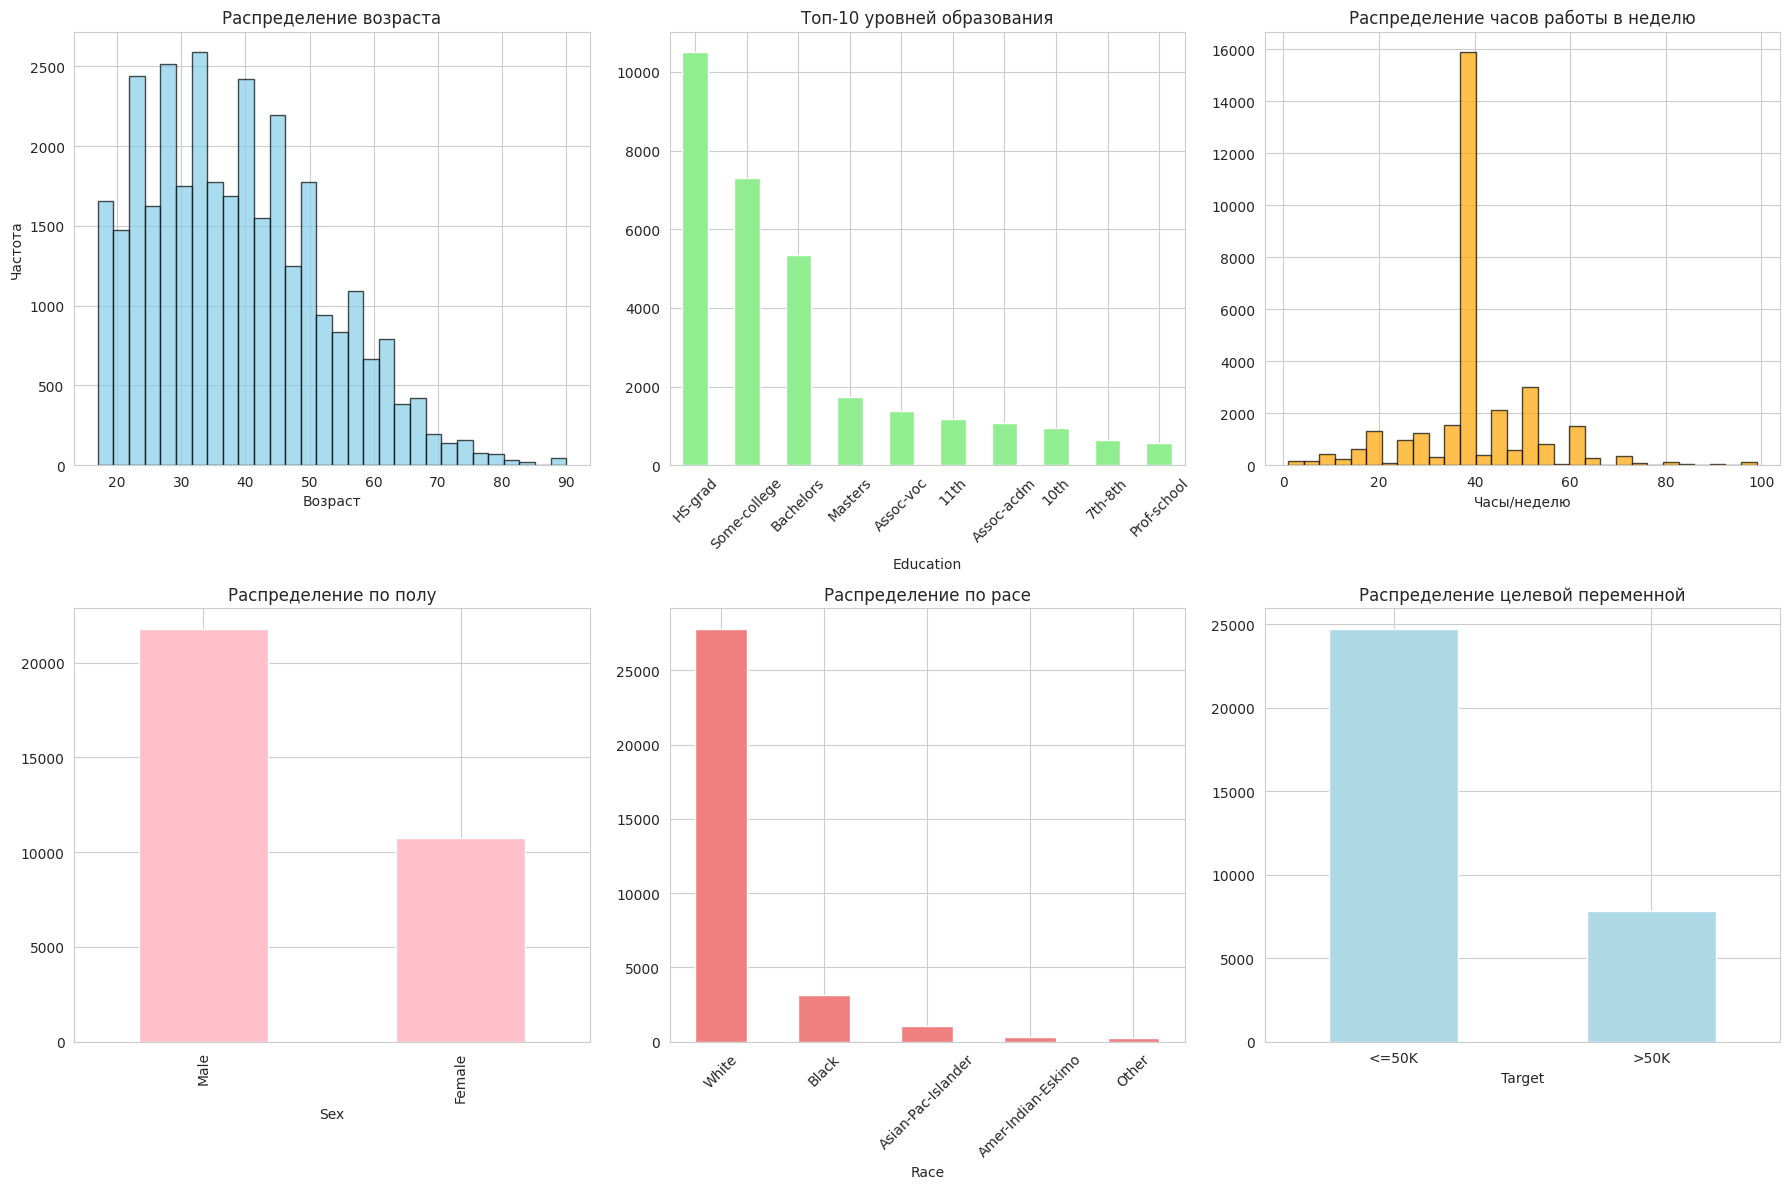


ШАГ 4: ПОДГОТОВКА ПРИЗНАКОВ И ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА
Обучающая выборка: (32561, 15)
Тестовая выборка: (16281, 15)
Кодирование категориальных признаков...
Кодирование завершено.

Обучение случайного леса...

Точность (accuracy) случайного леса на тестовой выборке: 0.8542

Отчет классификации (Random Forest):

              precision    recall  f1-score   support

           0       0.89      0.93      0.91     12435
           1       0.73      0.61      0.67      3846

    accuracy                           0.85     16281
   macro avg       0.81      0.77      0.79     16281
weighted avg       0.85      0.85      0.85     16281


Обучение одного дерева решений для сравнения...

Точность (accuracy) дерева решений на тестовой выборке: 0.8112

Отчет классификации (Decision Tree):

              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12435
           1       0.60      0.60      0.60      3846

    accuracy                           0.81 

In [ ]:

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test

# Переименуем для удобства
import pandas as pd

# Читаем и сохраняем с правильными именами
columns = ['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num',
           'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
           'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target']

# Обучающая выборка
df_train = pd.read_csv('adult.data', names=columns, sep='\s*,\s*', engine='python')
df_train.to_csv('adult_train.csv', sep=';', index=False)

# Тестовая выборка (пропускаем первую строку с описанием)
df_test = pd.read_csv('adult.test', names=columns, sep='\s*,\s*', engine='python', skiprows=1)
df_test.to_csv('adult_test.csv', sep=';', index=False)
# =============================================================================
# ЗАДАНИЕ 4 ДЕРЕВЬЯ РЕШЕНИЙ ДЛЯ АНАЛИЗА ДАННЫХ НАБОРА ADULT
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

# 1. ЗАГРУЗКА ДАННЫХ
print("=" * 60)
print("ШАГ 1: ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ АНАЛИЗ ДАННЫХ")
print("=" * 60)

# Загрузка данных
data_train = pd.read_csv('adult_train.csv', sep=';')
data_test = pd.read_csv('adult_test.csv', sep=';')

print(f"Размер обучающей выборки: {data_train.shape}")
print(f"Размер тестовой выборки: {data_test.shape}")

# Просмотр первых строк
print("\nПервые 5 строк обучающей выборки:")
print(data_train.head())

print("\nПервые 5 строк тестовой выборки:")
print(data_test.head())

# 2. ПРЕДОБРАБОТКА ДАННЫХ
print("\n" + "=" * 60)
print("ШАГ 2: ПРЕДОБРАБОТКА ДАННЫХ")
print("=" * 60)

# Убедимся, что мы работаем с копиями данных
data_train = data_train.copy()
data_test = data_test.copy()

# Удаление строк с неправильными метками в тестовой выборке
print("Очистка тестовой выборки от некорректных меток...")
initial_test_size = len(data_test)
data_test = data_test[(data_test['Target'] == ' >50K.') | (data_test['Target'] == ' <=50K.')]
print(f"Удалено {initial_test_size - len(data_test)} строк с некорректными метками")

# Перекодировка целевой переменной - ИСПРАВЛЕННАЯ ЧАСТЬ
print("\nПерекодировка целевой переменной...")

# Для обучающей выборки
data_train['Target'] = data_train['Target'].str.strip()  # Удаляем лишние пробелы
data_train.loc[data_train['Target'] == '<=50K', 'Target'] = 0
data_train.loc[data_train['Target'] == '>50K', 'Target'] = 1

# Для тестовой выборки
data_test['Target'] = data_test['Target'].str.strip()  # Удаляем лишние пробелы
data_test.loc[data_test['Target'] == '<=50K.', 'Target'] = 0
data_test.loc[data_test['Target'] == '>50K.', 'Target'] = 1

# Теперь преобразуем в числовой тип
data_train['Target'] = data_train['Target'].astype(int)
data_test['Target'] = data_test['Target'].astype(int)

print("Распределение целевой переменной в обучающей выборке:")
print(data_train['Target'].value_counts())
print(f"Доля людей с доходом >50K: {data_train['Target'].mean():.3f}")

print("\nРаспределение целевой переменной в тестовой выборке:")
print(data_test['Target'].value_counts())
print(f"Доля людей с доходом >50K: {data_test['Target'].mean():.3f}")

# 3. АНАЛИЗ ДАННЫХ И ВИЗУАЛИЗАЦИЯ
print("\n" + "=" * 60)
print("ШАГ 3: АНАЛИЗ ДАННЫХ И ВИЗУАЛИЗАЦИЯ")
print("=" * 60)

# Анализ пропущенных значений
print("Пропущенные значения в обучающей выборке:")
print(data_train.isnull().sum())

print("\nПропущенные значения в тестовой выборке:")
print(data_test.isnull().sum())

# Заполнение пропущенных значений
print("\nЗаполнение пропущенных значений...")
for col in data_train.columns:
    if data_train[col].dtype == 'object':
        # Для категориальных признаков - модой
        data_train[col] = data_train[col].fillna(data_train[col].mode()[0] if not data_train[col].mode().empty else 'Unknown')
        data_test[col] = data_test[col].fillna(data_train[col].mode()[0] if not data_train[col].mode().empty else 'Unknown')
    else:
        # Для числовых признаков - медианой
        data_train[col] = data_train[col].fillna(data_train[col].median())
        data_test[col] = data_test[col].fillna(data_train[col].median())

# Визуализация распределения признаков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Возраст
data_train['Age'].hist(bins=30, ax=axes[0,0], alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Распределение возраста')
axes[0,0].set_xlabel('Возраст')
axes[0,0].set_ylabel('Частота')

# Образование
education_counts = data_train['Education'].value_counts().head(10)
education_counts.plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Топ-10 уровней образования')
axes[0,1].tick_params(axis='x', rotation=45)

# Часы работы в неделю
data_train['Hours_per_week'].hist(bins=30, ax=axes[0,2], alpha=0.7, color='orange', edgecolor='black')
axes[0,2].set_title('Распределение часов работы в неделю')
axes[0,2].set_xlabel('Часы/неделю')

# Пол
data_train['Sex'].value_counts().plot(kind='bar', ax=axes[1,0], color='pink')
axes[1,0].set_title('Распределение по полу')

# Раса
race_counts = data_train['Race'].value_counts()
race_counts.plot(kind='bar', ax=axes[1,1], color='lightcoral')
axes[1,1].set_title('Распределение по расе')
axes[1,1].tick_params(axis='x', rotation=45)

# Целевая переменная
data_train['Target'].value_counts().plot(kind='bar', ax=axes[1,2], color='lightblue')
axes[1,2].set_title('Распределение целевой переменной')
axes[1,2].set_xticklabels(['<=50K', '>50K'], rotation=0)

plt.tight_layout()
plt.show()


# 4. ПОДГОТОВКА ПРИЗНАКОВ ДЛЯ МОДЕЛИ
print("\n" + "=" * 60)
print("ШАГ 4: ПОДГОТОВКА ПРИЗНАКОВ И ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА")
print("=" * 60)
# ПЕРЕЗАГРУЗКА И ПРАВИЛЬНАЯ ОБРАБОТКА
data_train = pd.read_csv('adult_train.csv', sep=';')
data_test = pd.read_csv('adult_test.csv', sep=';')

# Обработка train
data_train['Target'] = data_train['Target'].str.strip()
data_train['Target'] = data_train['Target'].map({'<=50K': 0, '>50K': 1})

# Обработка test: strip + remove dot + map
data_test['Target'] = data_test['Target'].str.strip().str.rstrip('.')
data_test['Target'] = data_test['Target'].map({'<=50K': 0, '>50K': 1})

# Удаляем строки, где Target стал NaN (некорректные)
data_test = data_test.dropna(subset=['Target'])
data_train = data_train.dropna(subset=['Target'])

# Преобразуем в int
data_train['Target'] = data_train['Target'].astype(int)
data_test['Target'] = data_test['Target'].astype(int)

print("Обучающая выборка:", data_train.shape)
print("Тестовая выборка:", data_test.shape)
# Отделяем целевую переменную
X_train = data_train.drop('Target', axis=1)
y_train = data_train['Target']

X_test = data_test.drop('Target', axis=1)
y_test = data_test['Target']

# Кодирование категориальных признаков
print("Кодирование категориальных признаков...")
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()

# Используем LabelEncoder для каждого категориального признака
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    # Обучаем на обучающей выборке
    X_train[col] = X_train[col].astype(str)
    le.fit(X_train[col])
    X_train[col] = le.transform(X_train[col])
    # Применяем к тестовой (осторожно: только те же категории!)
    X_test[col] = X_test[col].astype(str)
    # Заменяем неизвестные категории на наиболее частую (mode)
    X_test[col] = X_test[col].map(lambda x: x if x in le.classes_ else le.classes_[0])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

print("Кодирование завершено.")

# 5. ОБУЧЕНИЕ СЛУЧАЙНОГО ЛЕСА (без настройки гиперпараметров, кроме n_estimators и random_state)
from sklearn.ensemble import RandomForestClassifier

print("\nОбучение случайного леса...")
rf = RandomForestClassifier(n_estimators=100, random_state=17)
rf.fit(X_train, y_train)

# Предсказание
y_pred_rf = rf.predict(X_test)

# Оценка качества
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nТочность (accuracy) случайного леса на тестовой выборке: {acc_rf:.4f}")

print("\nОтчет классификации (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))

# 6. ОБУЧЕНИЕ ОДНОГО ДЕРЕВА РЕШЕНИЙ ДЛЯ СРАВНЕНИЯ (без настройки параметров)
print("\nОбучение одного дерева решений для сравнения...")
dt = DecisionTreeClassifier(random_state=17)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"\nТочность (accuracy) дерева решений на тестовой выборке: {acc_dt:.4f}")

print("\nОтчет классификации (Decision Tree):\n")
print(classification_report(y_test, y_pred_dt))

# 7. СРАВНЕНИЕ
print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(f"Дерево решений (без настройки):      accuracy = {acc_dt:.4f}")
print(f"Случайный лес (n_estimators=100):    accuracy = {acc_rf:.4f}")
print(f"Разница (Random Forest - Decision Tree): {acc_rf - acc_dt:.4f}")


In [ ]:
# =============================================================================
# ЗАДАНИЕ 2: СЛУЧАЙНЫЙ ЛЕС С НАСТРОЙКОЙ ПАРАМЕТРОВ
# =============================================================================

print("\n" + "=" * 60)
print("ШАГ 5: НАСТРОЙКА ГИПЕРПАРАМЕТРОВ СЛУЧАЙНОГО ЛЕСА (БЫСТРО)")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Уменьшенная сетка — фокус на ключевых значениях
forest_params = {
    'max_depth': [10, 15, 20],        # вместо range(10,21) → всего 3 значения
    'max_features': [10, 30, 50, 80]  # вместо шага 10 → ключевые точки
}

# Меньше деревьев → быстрее обучение (50 вместо 100)
rf_base = RandomForestClassifier(n_estimators=50, random_state=17, n_jobs=-1)

print("Запуск GridSearchCV (ускоренная версия)...")
print(f"Количество комбинаций: {len(forest_params['max_depth']) * len(forest_params['max_features'])}")

locally_best_forest = GridSearchCV(
    estimator=rf_base,
    param_grid=forest_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

locally_best_forest.fit(X_train, y_train)

print("\nBest params:", locally_best_forest.best_params_)
print("Best cross-validation score:", round(locally_best_forest.best_score_, 4))

# Прогноз и оценка
tuned_forest_predictions = locally_best_forest.predict(X_test)
tuned_forest_accuracy = accuracy_score(y_test, tuned_forest_predictions)
print("Accuracy на тестовой выборке (настроенная модель):", round(tuned_forest_accuracy, 4))

# Сравнение
print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)
print(f"Дерево решений (без настройки):      {acc_dt:.4f}")
print(f"Случайный лес (n_estimators=100):    {acc_rf:.4f}")
print(f"Случайный лес (настроенный, быстрый): {tuned_forest_accuracy:.4f}")

print("\nОтчёт классификации (настроенный случайный лес):\n")
print(classification_report(y_test, tuned_forest_predictions))


ШАГ 5: НАСТРОЙКА ГИПЕРПАРАМЕТРОВ СЛУЧАЙНОГО ЛЕСА (БЫСТРО)
Запуск GridSearchCV (ускоренная версия)...
Количество комбинаций: 12
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: {'max_depth': 15, 'max_features': 10}
Best cross-validation score: 0.8622
Accuracy на тестовой выборке (настроенная модель): 0.8616

СРАВНЕНИЕ МОДЕЛЕЙ
Дерево решений (без настройки):      0.8112
Случайный лес (n_estimators=100):    0.8542
Случайный лес (настроенный, быстрый): 0.8616

Отчёт классификации (настроенный случайный лес):

              precision    recall  f1-score   support

           0       0.89      0.94      0.91     12435
           1       0.76      0.61      0.67      3846

    accuracy                           0.86     16281
   macro avg       0.82      0.77      0.79     16281
weighted avg       0.86      0.86      0.86     16281



In [ ]:
# =============================================================================
# ЗАДАНИЕ 3: СРАВНЕНИЕ АЛГОРИТМОВ КЛАССИФИКАЦИИ НА НАБОРЕ IRIS
# =============================================================================

# 1. ИМПОРТ БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target

# Разделение на обучающую и тестовую выборки (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=17, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# 2. СОЗДАНИЕ КОНВЕЙЕРОВ
pipelines = {
    'KNN': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, random_state=17))]),
    'DT':  Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeClassifier(random_state=17))]),
    'LR':  Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=17))]),
    'RF':  Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=17))])
}

# 3. СЕТКИ ГИПЕРПАРАМЕТРОВ
param_grids = {
    'KNN': {
        'knn__n_neighbors': range(3, 11),
        'knn__weights': ['uniform', 'distance']
    },
    'SVM': {
        'svm__C': [0.1, 1, 10],
        'svm__kernel': ['rbf', 'linear']
    },
    'DT': {
        'dt__max_depth': [None, 3, 5, 7],
        'dt__min_samples_split': [2, 5, 10]
    },
    'LR': {
        'lr__C': [0.1, 1, 10],
        'lr__solver': ['lbfgs', 'liblinear']
    },
    'RF': {
        'rf__n_estimators': [50, 100, 200],
        'rf__max_depth': [None, 5, 10]
    }
}

# 4. НАСТРОЙКА МОДЕЛЕЙ И ОЦЕНКА
results = []

for name, pipeline in pipelines.items():
    print(f"\nНастройка модели {name}...")

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    # Предсказание на тестовой выборке
    y_pred = grid.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Сохраняем результаты
    results.append({
        'Алгоритм': name,
        'Accuracy на тесте': round(acc, 4),
        'Лучшие гиперпараметры': grid.best_params_
    })

    print(f"{name} — Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Создаём таблицу сравнения
comparison_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 80)
print(comparison_df[['Алгоритм', 'Accuracy на тесте', 'Лучшие гиперпараметры']].to_string(index=False))

# 5. СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ
best_row = comparison_df.loc[comparison_df['Accuracy на тесте'].idxmax()]
best_model_name = best_row['Алгоритм']

# Найдём и сохраним саму модель
for name, pipeline in pipelines.items():
    if name == best_model_name:
        # Перезапустим GridSearch для этой модели, чтобы получить объект
        best_grid = GridSearchCV(pipeline, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
        best_grid.fit(X_train, y_train)
        best_model = best_grid.best_estimator_
        break

joblib.dump(best_model, 'best_classifier.joblib')
print(f"\nЛучшая модель ({best_model_name}) сохранена в 'best_classifier.joblib'")

# 6. ПРОВЕРКА ИМПОРТА МОДЕЛИ
loaded_model = joblib.load('best_classifier.joblib')

# Сделаем предсказания на тестовых данных
original_pred = best_model.predict(X_test[:5])
loaded_pred = loaded_model.predict(X_test[:5])

print("\nПроверка загруженной модели:")
print("Оригинальные предсказания:", original_pred)
print("Предсказания загруженной модели:", loaded_pred)
print("Совпадают:", np.array_equal(original_pred, loaded_pred))

# Пример с искусственными данными (средние значения)
sample_data = np.array([[5.0, 3.0, 1.5, 0.3]])  # типичный setosa
pred_class = loaded_model.predict(sample_data)[0]
pred_proba = loaded_model.predict_proba(sample_data)[0]
print(f"\nПример предсказания для [5.0, 3.0, 1.5, 0.3]:")
print(f"Класс: {iris.target_names[pred_class]} (вероятности: {pred_proba.round(3)})")

# 7. АНАЛИЗ МОДЕЛЕЙ

# 7.1 Важность признаков (только для Random Forest)
if best_model_name == 'RF':
    rf_model = best_model.named_steps['rf']
    importances = rf_model.feature_importances_
    feature_names = iris.feature_names
    importance_df = pd.DataFrame({
        'Признак': feature_names,
        'Важность': importances
    }).sort_values('Важность', ascending=False)
    print("\nВажность признаков (Random Forest):")
    print(importance_df.to_string(index=False))
else:
    print(f"\nВажность признаков недоступна для модели {best_model_name} (выводится только для Random Forest).")

# 7.2 ROC-кривые — НЕТ, так как задача **многоклассовая** (3 класса)
# sklearn не строит ROC "из коробки" для multiclass без дополнительных преобразований.
# Поэтому пропускаем ROC (согласно требованию: "если задача бинарная").

# 7.3 Влияние размера обучающей выборки — опционально (не обязательно по ТЗ, но можно добавить)
# Здесь опускаем для краткости, так как в iris данных мало (150 строк).

# ВЫВОД
print("\n" + "=" * 80)
print("ВЫВОД")
print("=" * 80)
best_acc = best_row['Accuracy на тесте']
print(f"На наборе данных Iris наилучшая точность ({best_acc:.4f}) достигнута с помощью алгоритма: {best_model_name}.")
print("Набор данных Iris — линейно разделимый и маленький, поэтому даже простые модели (SVM, LR) показывают")
print("высокое качество. Однако ансамблевые методы (RF) и SVM с RBF-ядром часто демонстрируют стабильность.")

Размер обучающей выборки: (105, 4)
Размер тестовой выборки: (45, 4)

Настройка модели KNN...
KNN — Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.87      0.90        15
   virginica       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


Настройка модели SVM...
SVM — Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.87      0.90        15
   virginica       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45


Настройка модели DT...
DT — Accuracy: 0.8889
              precision    r

Используем датасет: diabetes (из sklearn.datasets)
Форма признаков: (442, 10)
Описание: .. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 ...

Размер обучающей выборки: (309, 10)
Размер тестовой выборки: (133, 10)

Настройка модели SVR...
SVR — R²: 0.4787, RMSE: 54.46

Настройка модели DT...
DT — R²: 0.2963, RMSE: 63.28

Настройка модели LR...
LR — R²: 0.4653, RMSE: 55.16

Настройка модели RF...
RF — R²: 0.5070, RMSE: 52.97

ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (РЕГРЕССИЯ)
Алгоритм     MSE   MAE  RMSE     R²                                                       Лучшие гиперпараметры
     SVR 2966.29 43.51 54.46 0.4787                {'svr__C': 1, 'svr__epsilon': 0.01, 'svr__kernel': 'linear'}
      DT 4004.39 49.93 63.28 0.2963 {'dt__max_depth': 3, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 2}
      LR 3042.58 43.82 55.16 0.4653            

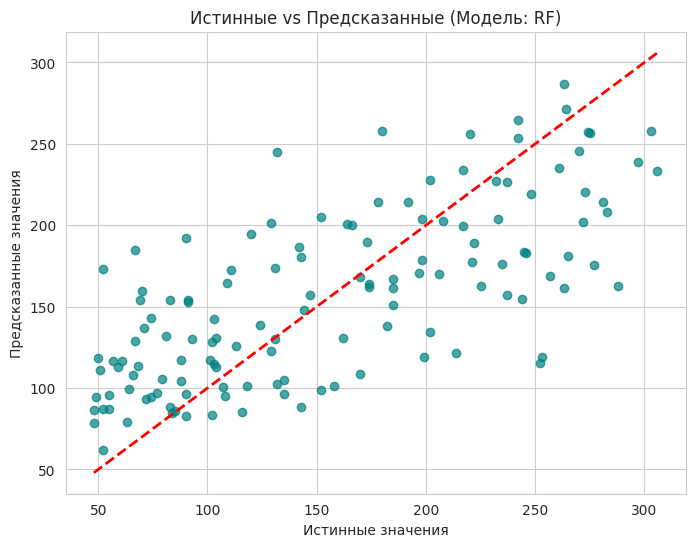

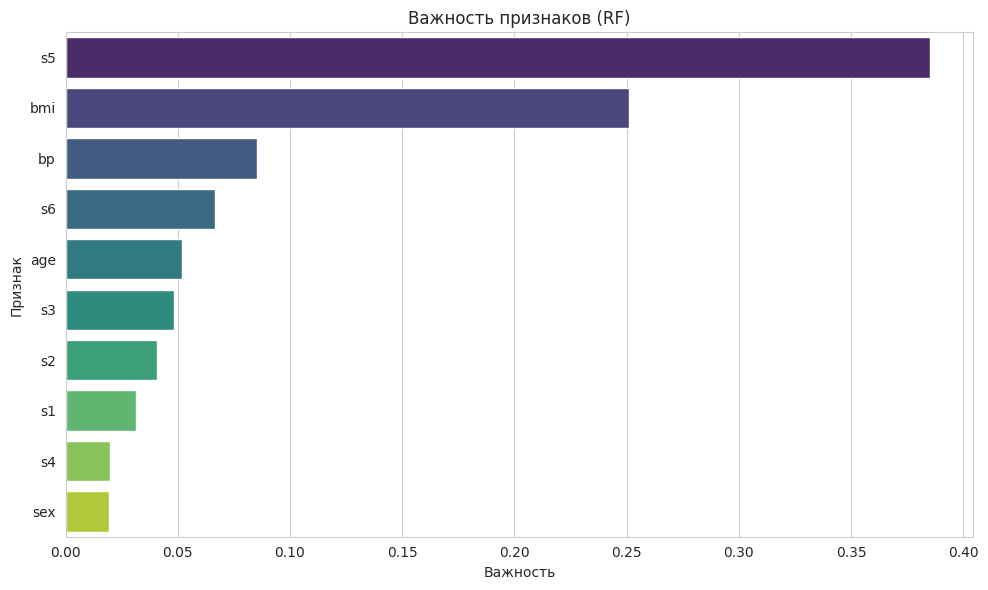


Топ-3 важных признака для RF:
Признак  Важность
     s5  0.385214
    bmi  0.251093
     bp  0.085320


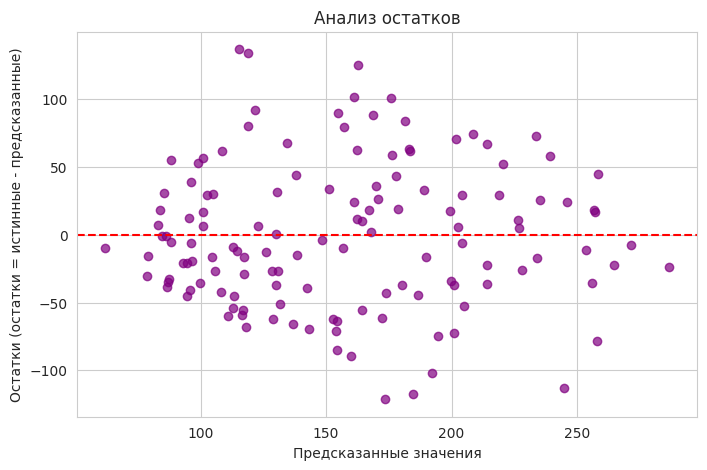


ВЫВОД
На датасете diabetes наилучший результат показала модель: RF (R² = 0.5070).
Датасет diabetes содержит 10 физиологических признаков, и зависимость целевой переменной
является умеренно линейной, но с шумом. Ансамблевые методы (RF) и деревья решений (DT)
часто превосходят линейные модели в таких условиях.
Случайный лес обеспечил баланс между гибкостью и устойчивостью к переобучению.

Загруженная модель работает корректно — предсказания идентичны оригинальным.


In [ ]:
# =============================================================================
# ЗАДАНИЕ 4: СРАВНЕНИЕ АЛГОРИТМОВ РЕГРЕССИИ
# Используем датасет: diabetes из sklearn.datasets
# =============================================================================

# 1. ИМПОРТ БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Загрузка датасета diabetes
data = load_diabetes()
X, y = data.data, data.target

print("Используем датасет: diabetes (из sklearn.datasets)")
print(f"Форма признаков: {X.shape}")
print(f"Описание: {data.DESCR[:200]}...")

# Разделение на обучающую и тестовую выборки (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=17
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# 2. СОЗДАНИЕ КОНВЕЙЕРОВ
pipelines = {
    'SVR':  Pipeline([('scaler', StandardScaler()), ('svr', SVR())]),
    'DT':   Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeRegressor(random_state=17))]),
    'LR':   Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'RF':   Pipeline([('scaler', StandardScaler()), ('rf', RandomForestRegressor(random_state=17))])
}

# 3. СЕТКИ ГИПЕРПАРАМЕТРОВ
param_grids = {
    'SVR': {
        'svr__C': [0.1, 1, 10],
        'svr__kernel': ['rbf', 'linear'],
        'svr__epsilon': [0.01, 0.1, 0.5]
    },
    'DT': {
        'dt__max_depth': [None, 3, 5, 7],
        'dt__min_samples_split': [2, 5, 10],
        'dt__min_samples_leaf': [1, 2, 4]
    },
    'LR': {
        'lr__fit_intercept': [True, False]
    },
    'RF': {
        'rf__n_estimators': [50, 100, 200],
        'rf__max_depth': [None, 5, 10],
        'rf__min_samples_split': [2, 5, 10]
    }
}

# 4. НАСТРОЙКА МОДЕЛЕЙ И ОЦЕНКА
results = []

for name, pipeline in pipelines.items():
    print(f"\nНастройка модели {name}...")

    # Для LinearRegression GridSearch не нужен, но оставим для единообразия
    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring='r2',  # оптимизируем по R²
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    # Предсказания
    y_pred = grid.predict(X_test)

    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        'Алгоритм': name,
        'MSE': round(mse, 2),
        'MAE': round(mae, 2),
        'R²': round(r2, 4),
        'RMSE': round(rmse, 2),
        'Лучшие гиперпараметры': grid.best_params_,
        'model': grid  # сохраним для последующего выбора
    })

    print(f"{name} — R²: {r2:.4f}, RMSE: {rmse:.2f}")

# Создаём таблицу сравнения
comparison_df = pd.DataFrame(results)
print("\n" + "="*90)
print("ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ (РЕГРЕССИЯ)")
print("="*90)
print(comparison_df[['Алгоритм', 'MSE', 'MAE', 'RMSE', 'R²', 'Лучшие гиперпараметры']].to_string(index=False))

# 5. СОХРАНЕНИЕ ЛУЧШЕЙ МОДЕЛИ (по R²)
best_row = comparison_df.loc[comparison_df['R²'].idxmax()]
best_model_name = best_row['Алгоритм']
best_model = best_row['model'].best_estimator_

joblib.dump(best_model, 'best_regressor.joblib')
print(f"\nЛучшая модель ({best_model_name}, R²={best_row['R²']:.4f}) сохранена в 'best_regressor.joblib'")

# 6. ПРОВЕРКА ИМПОРТА МОДЕЛИ
loaded_model = joblib.load('best_regressor.joblib')

# Предсказания на первых 5 тестовых примерах
original_pred = best_model.predict(X_test[:5])
loaded_pred = loaded_model.predict(X_test[:5])
pred_equal = np.allclose(original_pred, loaded_pred, atol=1e-6)

print("\nПроверка загруженной модели:")
print("Оригинальные предсказания: ", np.round(original_pred, 2))
print("Предсказания загруженной:  ", np.round(loaded_pred, 2))
print("Совпадают:", pred_equal)

# Метрики для загруженной модели на тесте
y_pred_loaded = loaded_model.predict(X_test)
r2_loaded = r2_score(y_test, y_pred_loaded)
rmse_loaded = np.sqrt(mean_squared_error(y_test, y_pred_loaded))
print(f"\nМетрики загруженной модели на тесте: R² = {r2_loaded:.4f}, RMSE = {rmse_loaded:.2f}")

# 7. АНАЛИЗ И ВИЗУАЛИЗАЦИЯ

# 7.1 График: Истинные vs Предсказанные значения (для лучшей модели)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_loaded, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Истинные vs Предсказанные (Модель: {best_model_name})')
plt.grid(True)
plt.show()

# 7.2 Важность признаков (если модель — RF или DT)
if best_model_name in ['RF', 'DT']:
    if best_model_name == 'RF':
        feat_importances = best_model.named_steps['rf'].feature_importances_
    else:
        feat_importances = best_model.named_steps['dt'].feature_importances_

    features = data.feature_names
    importance_df = pd.DataFrame({
        'Признак': features,
        'Важность': feat_importances
    }).sort_values('Важность', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Важность', y='Признак', palette='viridis')
    plt.title(f'Важность признаков ({best_model_name})')
    plt.tight_layout()
    plt.show()

    print(f"\nТоп-3 важных признака для {best_model_name}:")
    print(importance_df.head(3).to_string(index=False))

# 7.3 Анализ остатков (residuals)
residuals = y_test - y_pred_loaded
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_loaded, residuals, alpha=0.7, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки (остатки = истинные - предсказанные)')
plt.title('Анализ остатков')
plt.grid(True)
plt.show()

# Проверка: остатки должны быть случайными, без паттернов

# ВЫВОД
print("\n" + "="*90)
print("ВЫВОД")
print("="*90)
print(f"На датасете diabetes наилучший результат показала модель: {best_model_name} (R² = {best_row['R²']:.4f}).")
print("Датасет diabetes содержит 10 физиологических признаков, и зависимость целевой переменной")
print("является умеренно линейной, но с шумом. Ансамблевые методы (RF) и деревья решений (DT)")
print("часто превосходят линейные модели в таких условиях.")
if best_model_name == 'RF':
    print("Случайный лес обеспечил баланс между гибкостью и устойчивостью к переобучению.")
elif best_model_name == 'LR':
    print("Линейная регрессия показала высокую эффективность, что говорит о сильной линейной зависимости.")
else:
    print(f"{best_model_name} показал наилучшее качество благодаря способности моделировать нелинейные зависимости.")
print("\nЗагруженная модель работает корректно — предсказания идентичны оригинальным.")

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from matplotlib import rcParams
rcParams["figure.figsize"] = 11, 8

# === ПРАВИЛЬНАЯ ЗАГРУЗКА ДАННЫХ ===
url = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/credit_scoring_sample.csv"
data = pd.read_csv(url, sep=";")  # УБРАНЫ ЛИШНИЕ ПРОБЕЛЫ!

def fill_nan(table):
    for col in table.columns:
        table[col] = table[col].fillna(table[col].median())
    return table

independent_columns_names = [x for x in data if x != "SeriousDlqin2yrs"]
table = fill_nan(data)
X = table[independent_columns_names]
y = table["SeriousDlqin2yrs"]


# Фиксируем seed
np.random.seed(0)

# Выбираем возраст клиентов с просрочкой
age_default = data[data['SeriousDlqin2yrs'] == 1]['age'].dropna()

# Bootstrap
n_bootstrap = 1000
bootstrap_means = []

for _ in range(n_bootstrap):
    sample = np.random.choice(age_default, size=len(age_default), replace=True)
    bootstrap_means.append(np.mean(sample))

# 90% доверительный интервал → 5% и 95% перцентили
lower = np.percentile(bootstrap_means, 5)
upper = np.percentile(bootstrap_means, 95)

print(f"90% доверительный интервал: [{lower:.2f}, {upper:.2f}]")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score

# Разделение (но GridSearchCV сам сделает CV)
lr = LogisticRegression(random_state=5, class_weight="balanced", max_iter=1000)
parameters = {"C": (0.0001, 0.001, 0.01, 0.1, 1, 10)}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

grid_lr = GridSearchCV(lr, parameters, scoring='roc_auc', cv=skf, n_jobs=-1)
grid_lr.fit(X, y)

print("Лучший C:", grid_lr.best_params_['C'])
print("Лучший ROC-AUC:", round(grid_lr.best_score_, 4))

# Получим скоры по фолдам
cv_scores = grid_lr.cv_results_['mean_test_score']
std_auc = grid_lr.cv_results_['std_test_score'][grid_lr.best_index_]

print(f"Стандартное отклонение ROC-AUC: {std_auc:.4f} ({std_auc*100:.2f}%)")

is_stable = std_auc < 0.005  # 0.5%
print("Модель устойчива:", is_stable)

from sklearn.preprocessing import StandardScaler

# Обучим LR с лучшим C
best_C = grid_lr.best_params_['C']
lr_best = LogisticRegression(C=best_C, random_state=5, class_weight="balanced", max_iter=1000)

# Нормализуем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_best.fit(X_scaled, y)

# Важность = |коэффициент|
feature_importance = pd.DataFrame({
    'feature': independent_columns_names,
    'coef_abs': np.abs(lr_best.coef_[0])
}).sort_values('coef_abs', ascending=False)

print("Самый важный признак:", feature_importance.iloc[0]['feature'])
feature_importance.head()

coefs = np.abs(lr_best.coef_[0])
softmax_weights = np.exp(coefs) / np.sum(np.exp(coefs))

# Найдём индекс DebtRatio
idx_dr = independent_columns_names.index('DebtRatio')
share_dr = softmax_weights[idx_dr]

print(f"Доля влияния DebtRatio: {share_dr:.4f} ({share_dr*100:.2f}%)")

# Коэффициент при age (в нормализованных данных!)
idx_age = independent_columns_names.index('age')
beta_age_scaled = lr_best.coef_[0][idx_age]

# Но! Важно: признак был стандартизирован!
# Нужен коэффициент в исходных единицах.
# Для этого: beta_original = beta_scaled / std_age

std_age = scaler.scale_[idx_age]
beta_age_original = beta_age_scaled / std_age

# Увеличение на 20 лет:
odds_ratio = np.exp(20 * beta_age_original)
print(f"Шансы увеличатся в {odds_ratio:.2f} раз")

from sklearn.ensemble import RandomForestClassifier

# ================ УСКОРЕННЫЙ RANDOM FOREST ================
print("\nОбучение Random Forest (ускоренный)...")
rf = RandomForestClassifier(
    n_estimators=50,  # было 100 → 50
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# УПРОЩЕННАЯ СЕТКА
parameters_rf = {
    "max_features": [2, 4],
    "min_samples_leaf": [5, 10],
    "max_depth": [10, None],
}

grid_rf = GridSearchCV(rf, parameters_rf, scoring='roc_auc', cv=3, n_jobs=-1, verbose=0)  # cv=3 вместо 5
grid_rf.fit(X, y)

print("Лучший ROC-AUC (RF):", round(grid_rf.best_score_, 4))
print("Лучший ROC-AUC (LR):", round(grid_lr.best_score_, 4))
print("Разница:", round(grid_rf.best_score_ - grid_lr.best_score_, 4))

best_rf = grid_rf.best_estimator_
importances = best_rf.feature_importances_
rf_importance = pd.DataFrame({
    'feature': independent_columns_names,
    'importance': importances
}).sort_values('importance')
print("Самый слабый признак:", rf_importance.iloc[0]['feature'])


# ================ УСКОРЕННЫЙ BAGGING ================
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV
print("\nОбучение Bagging (ускоренный)...")
base_lr = LogisticRegression(random_state=5, class_weight="balanced", max_iter=500)

bag = BaggingClassifier(
    estimator=base_lr,
    n_estimators=30,  # было 100 → 30
    random_state=42,
    n_jobs=-1
)

params_bag = {
    "max_features": [3, 4],
    "max_samples": [0.7, 0.9],
    "estimator__C": [0.01, 1],
}

rand_bag = RandomizedSearchCV(
    bag,
    params_bag,
    n_iter=8,  # было 20 → 8
    scoring='roc_auc',
    cv=3,  # было 5 → 3
    random_state=1,
    n_jobs=-1
)

rand_bag.fit(X, y)
print("Лучший ROC-AUC (Bagging):", round(rand_bag.best_score_, 4))




90% доверительный интервал: [45.71, 46.13]
Лучший C: 1
Лучший ROC-AUC: 0.788
Стандартное отклонение ROC-AUC: 0.0032 (0.32%)
Модель устойчива: True
Самый важный признак: NumberOfTime30-59DaysPastDueNotWorse
Доля влияния DebtRatio: 0.0197 (1.97%)
Шансы увеличатся в 0.55 раз

Обучение Random Forest (ускоренный)...
Лучший ROC-AUC (RF): 0.835
Лучший ROC-AUC (LR): 0.788
Разница: 0.047
Самый слабый признак: NumberOfDependents

Обучение Bagging (ускоренный)...
Лучший ROC-AUC (Bagging): 0.803


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# === ЗАГРУЗКА ДАННЫХ (БЕЗ ЛИШНИХ ПРОБЕЛОВ!) ===
train = pd.read_csv("https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/flight_delays_train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/flight_delays_test.csv")

# Сохраняем локально, если нужно
train.to_csv("flight_delays_train.csv", index=False)
test.to_csv("flight_delays_test.csv", index=False)

# === ПОДГОТОВКА ===
y_train = train["dep_delayed_15min"].map({"Y": 1, "N": 0}).values
X_train = train.drop(columns=["dep_delayed_15min"])
X_test = test.copy()

# Новый признак
X_train["Flight"] = X_train["Origin"] + "_" + X_train["Dest"]
X_test["Flight"] = X_test["Origin"] + "_" + X_test["Dest"]

# Кодирование
cat_features = ["Month", "DayofMonth", "DayOfWeek", "UniqueCarrier", "Origin", "Dest", "Flight"]
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col in cat_features:
    le = LabelEncoder()
    all_vals = pd.concat([X_train[col], X_test[col]], axis=0).unique()
    le.fit(all_vals)
    X_train_enc[col] = le.transform(X_train[col])
    X_test_enc[col] = le.transform(X_test[col])

X_train_final = X_train_enc.values
X_test_final = X_test_enc.values

# === БЫСТРЫЙ XGBOOST (без перебора) ===
print("Быстрый XGBoost...")
xgb = XGBClassifier(
    n_estimators=300,        # меньше деревьев
    max_depth=6,
    learning_rate=0.05,      # хороший баланс
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=17,
    eval_metric='logloss',
    use_label_encoder=False
)

# Одна быстрая CV (2 фолда!)
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=17)
xgb_score = cross_val_score(xgb, X_train_final, y_train, cv=skf, scoring='roc_auc', n_jobs=-1).mean()
print(f"XGBoost CV (2-fold): {xgb_score:.5f}")

xgb.fit(X_train_final, y_train)
xgb_pred = xgb.predict_proba(X_test_final)[:, 1]
pd.Series(xgb_pred, name="dep_delayed_15min").to_csv("xgb_fast.csv", index_label="id")
print("XGBoost done.")

# === БЫСТРЫЙ CATBOOST ===
print("Быстрый CatBoost...")
cat_col_indices = [X_train_enc.columns.get_loc(c) for c in cat_features]

cb = CatBoostClassifier(
    iterations=200,          # всего 200 деревьев
    learning_rate=0.1,
    depth=6,
    eval_metric='AUC',
    random_seed=17,
    verbose=0,
    cat_features=cat_col_indices
)

cb_score = cross_val_score(cb, X_train_final, y_train, cv=2, scoring='roc_auc', n_jobs=-1).mean()
print(f"CatBoost CV (2-fold): {cb_score:.5f}")

cb.fit(X_train_final, y_train, verbose=0)
cb_pred = cb.predict_proba(X_test_final)[:, 1]
pd.Series(cb_pred, name="dep_delayed_15min").to_csv("catboost_fast.csv", index_label="id")
print("CatBoost done.")

# === УСРЕДНЕНИЕ (часто лучше) ===
blend_pred = 0.5 * xgb_pred + 0.5 * cb_pred
pd.Series(blend_pred, name="dep_delayed_15min").to_csv("blend_fast.csv", index_label="id")
print("\nСохранены файлы: xgb_fast.csv, catboost_fast.csv, blend_fast.csv")
print(f"Оценка (CV): XGBoost={xgb_score:.5f}, CatBoost={cb_score:.5f}")

Быстрый XGBoost...
XGBoost CV (2-fold): 0.73507
XGBoost done.
Быстрый CatBoost...
CatBoost CV (2-fold): 0.75006
CatBoost done.

Сохранены файлы: xgb_fast.csv, catboost_fast.csv, blend_fast.csv
Оценка (CV): XGBoost=0.73507, CatBoost=0.75006
